<a href="https://colab.research.google.com/github/jyothisagar-analytics/jyothisagar-analytics/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Task: House PricePrediction (Regression)

import libariers

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

import dataset

In [3]:
df=pd.read_csv("house_price_regression_dataset.csv")

top 5 rows of dataset

In [4]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


bottom 5 rows of dataset

In [5]:
df.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [48]:
print(f"rows:{df.shape[0]}",f"columns:{df.shape[1]}")


rows:1000 columns:9


In [7]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [19]:
num_col=df.select_dtypes(include=["int64","float64"])
num_col

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [9]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [10]:
df.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


In [11]:
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


**data cleaning**

In [12]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


there are no missing values

In [13]:
df.duplicated().sum()

np.int64(0)

there are no duplicate values

**EXPLORATORY DATA ANALYSIS**

**UNIVARIENT ANALYSIS**

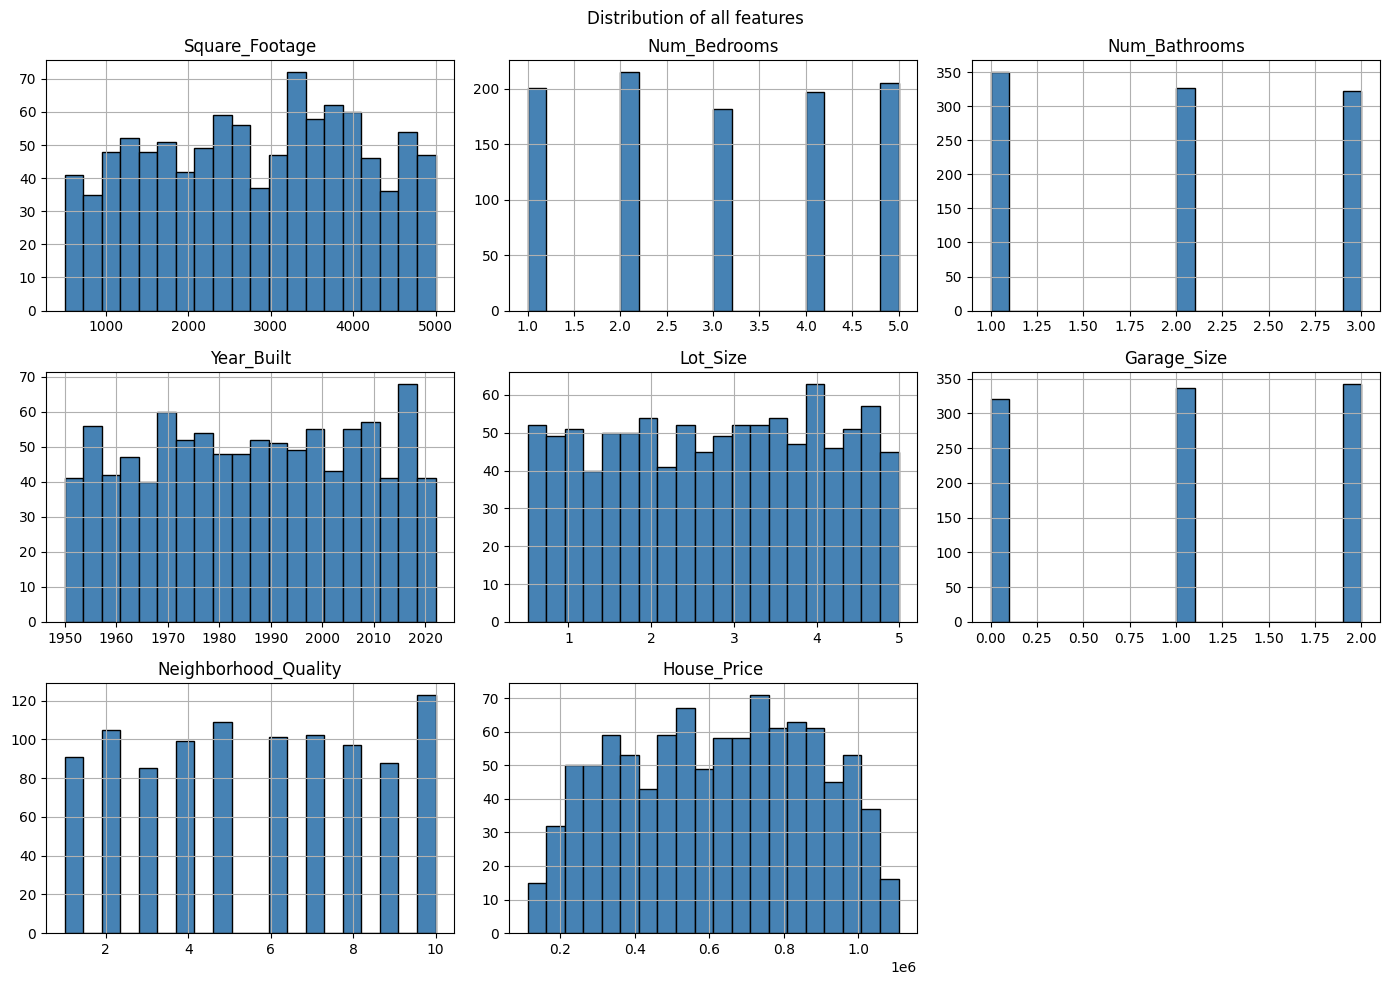

In [14]:
df.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of all features')
plt.tight_layout()
plt.show()

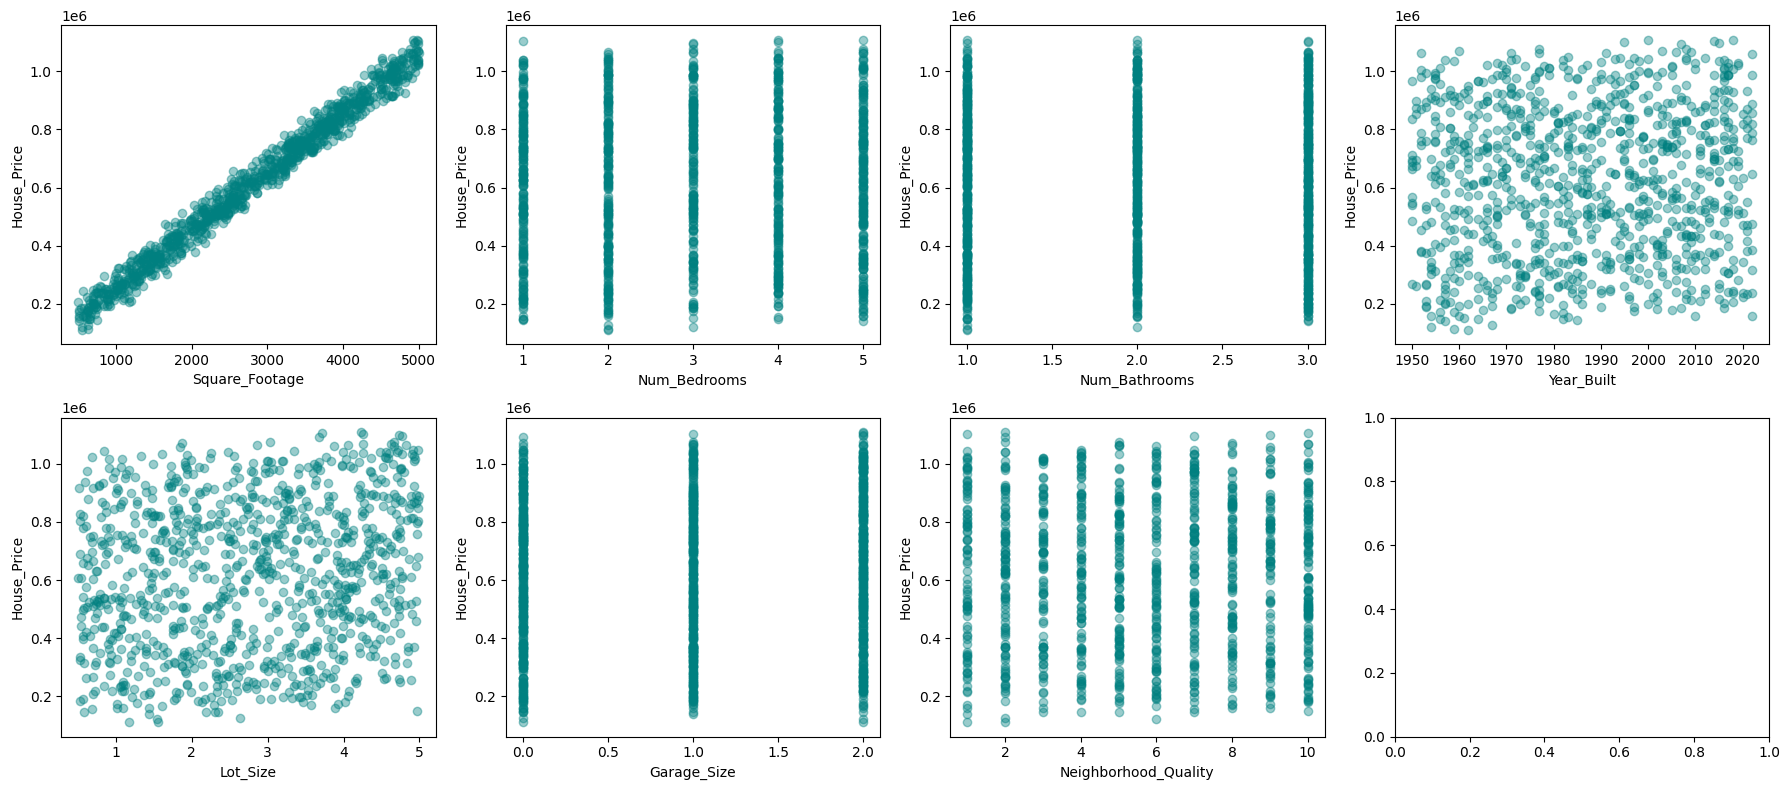

In [17]:
cols= ['Square_Footage','Num_Bedrooms','Num_Bathrooms',
            'Year_Built','Lot_Size','Garage_Size','Neighborhood_Quality']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(cols):
    axes[i//4][i%4].scatter(df[col], df['House_Price'], alpha=0.4, color='teal')
    axes[i//4][i%4].set_xlabel(col)
    axes[i//4][i%4].set_ylabel('House_Price')
plt.tight_layout()
plt.show()

<Figure size 500x200 with 0 Axes>

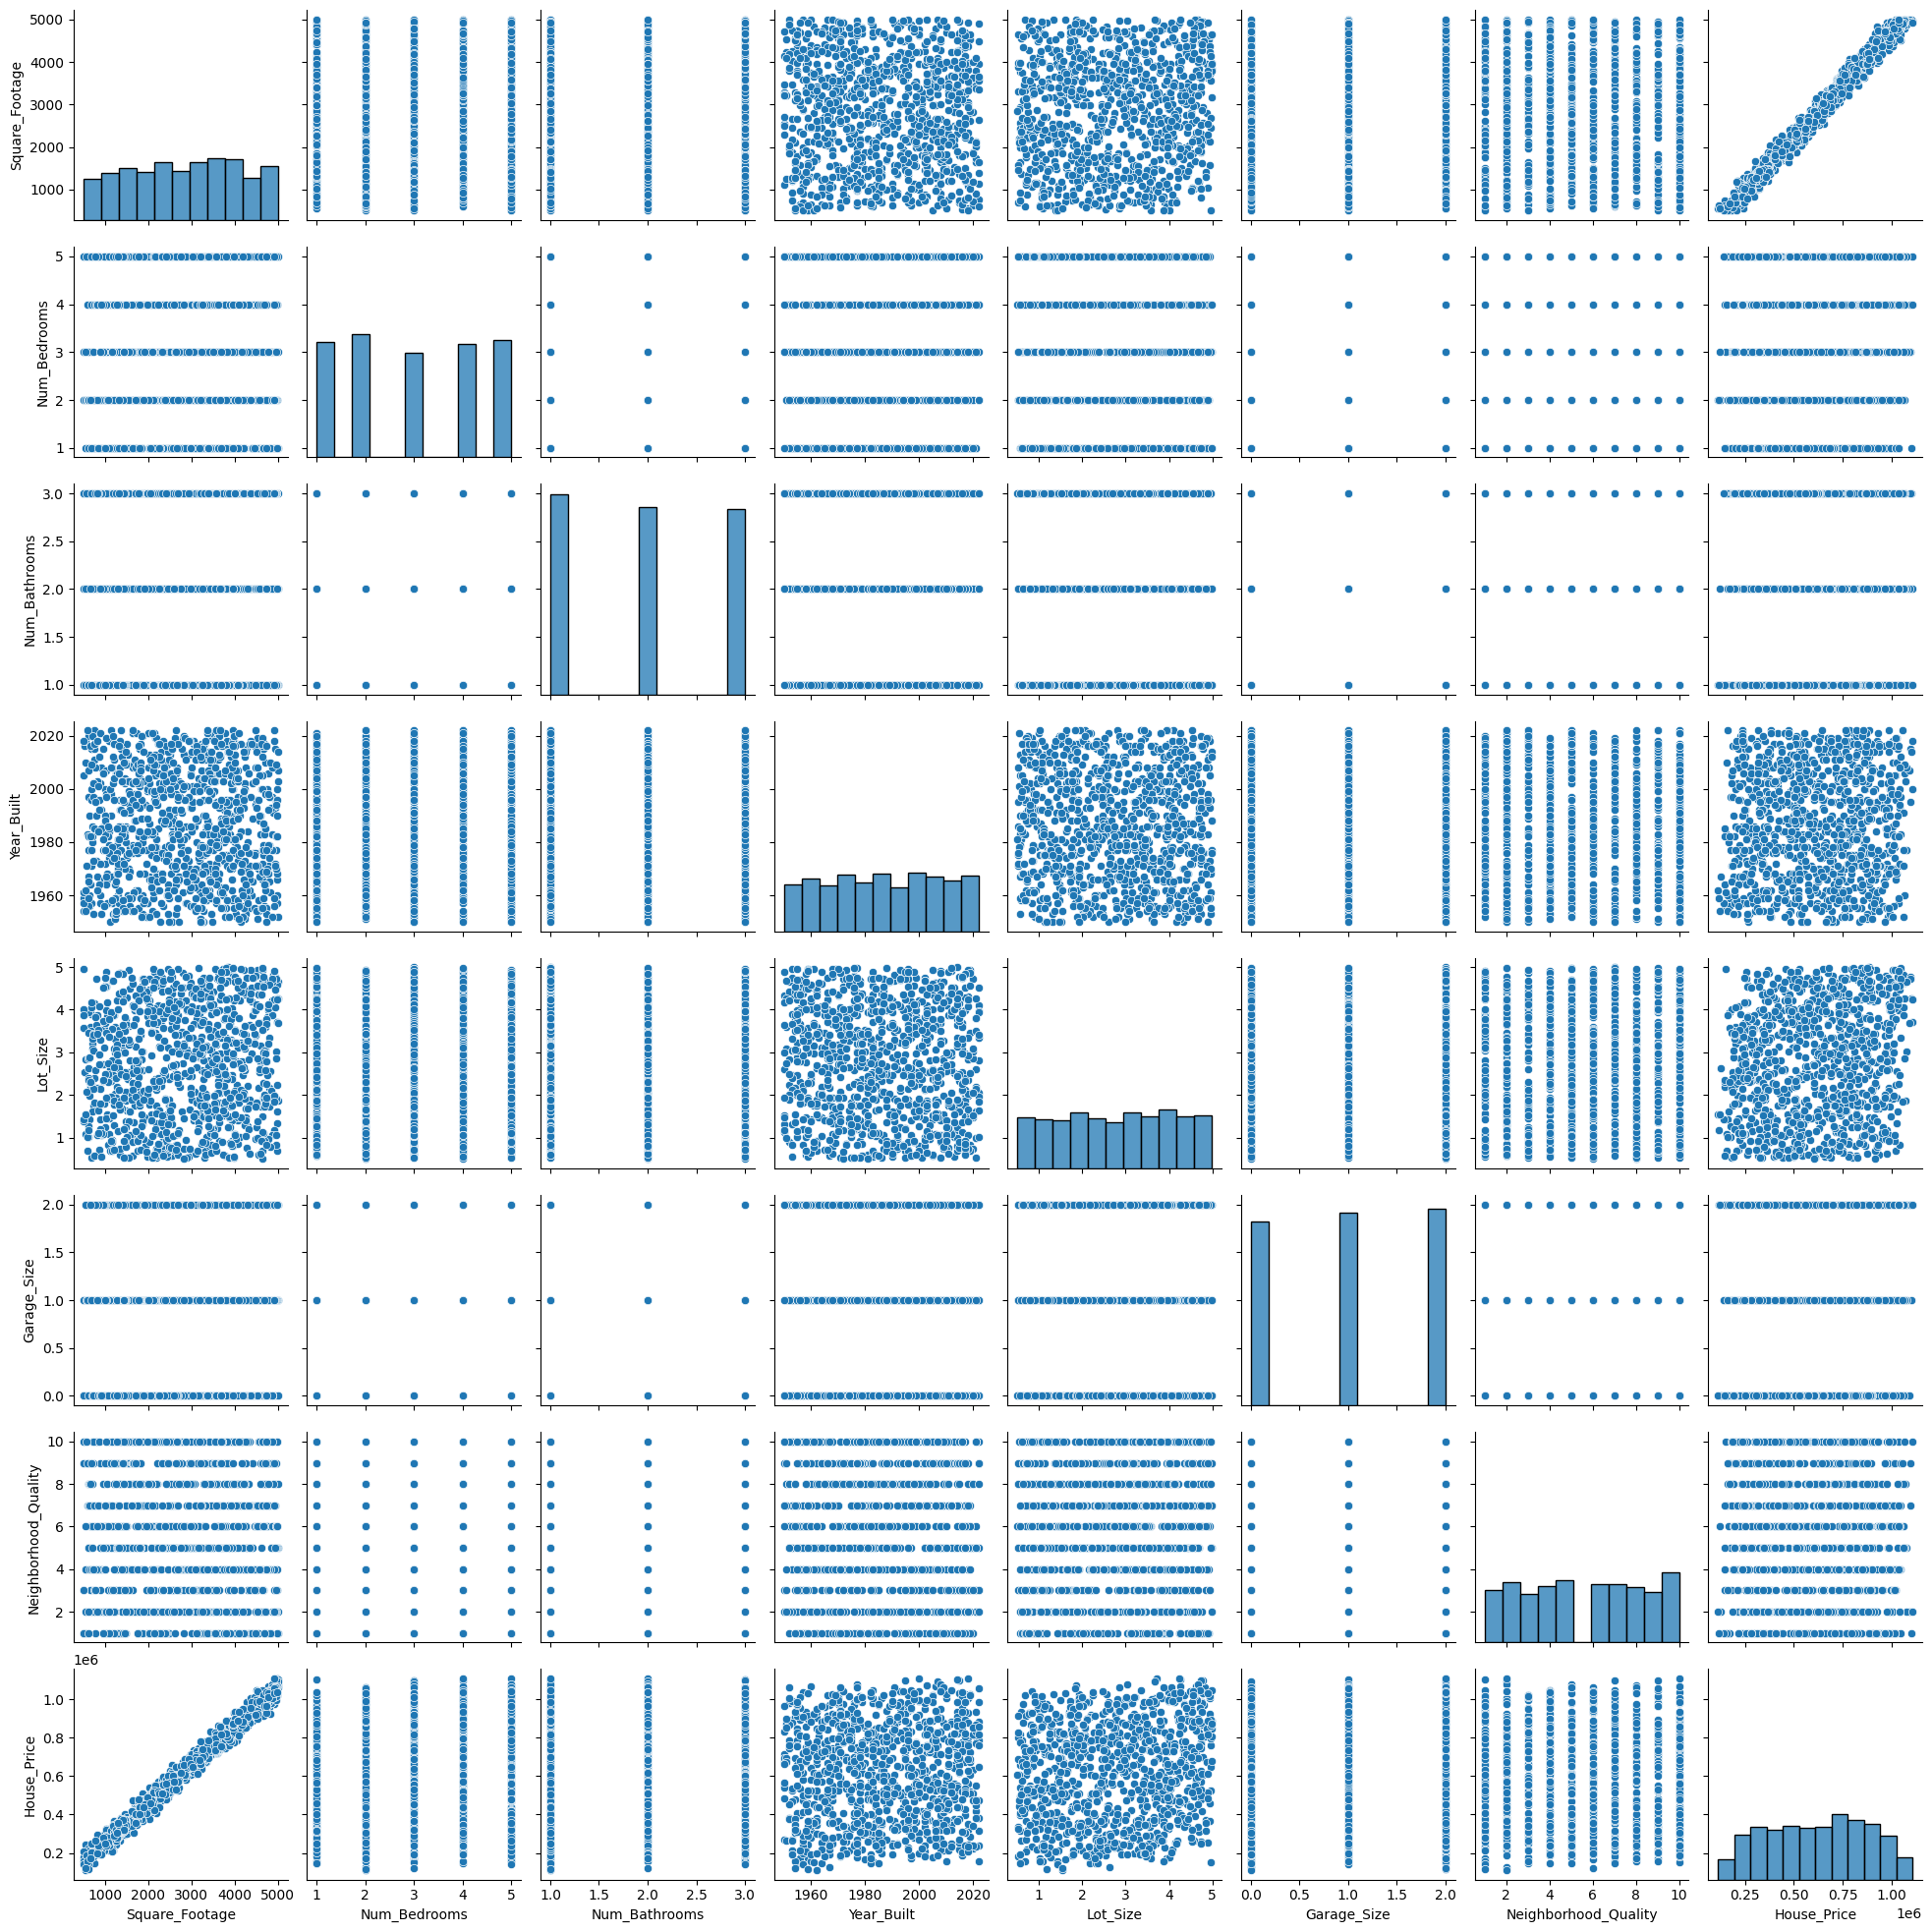

In [18]:
plt.figure(figsize=(5,2))
sns.pairplot(df)
plt.show()

In [20]:
corr=num_col.corr()
corr

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
Square_Footage,1.000000,-0.043564,-0.031584,-0.022392,0.089479,0.030593,-0.008357,0.991261
Num_Bedrooms,-0.043564,1.000000,0.022848,-0.015820,-0.009355,0.113761,-0.049024,0.014633
Num_Bathrooms,-0.031584,0.022848,1.000000,-0.021063,0.034923,0.024846,0.017585,-0.001862
Year_Built,-0.022392,-0.015820,-0.021063,1.000000,-0.061050,-0.025485,-0.009549,0.051967
Lot_Size,0.089479,-0.009355,0.034923,-0.061050,1.000000,0.002436,0.037630,0.160412
Garage_Size,0.030593,0.113761,0.024846,-0.025485,0.002436,1.000000,-0.011287,0.052133
Neighborhood_Quality,-0.008357,-0.049024,0.017585,-0.009549,0.037630,-0.011287,1.000000,-0.007770
House_Price,0.991261,0.014633,-0.001862,0.051967,0.160412,0.052133,-0.007770,1.000000


<Axes: >

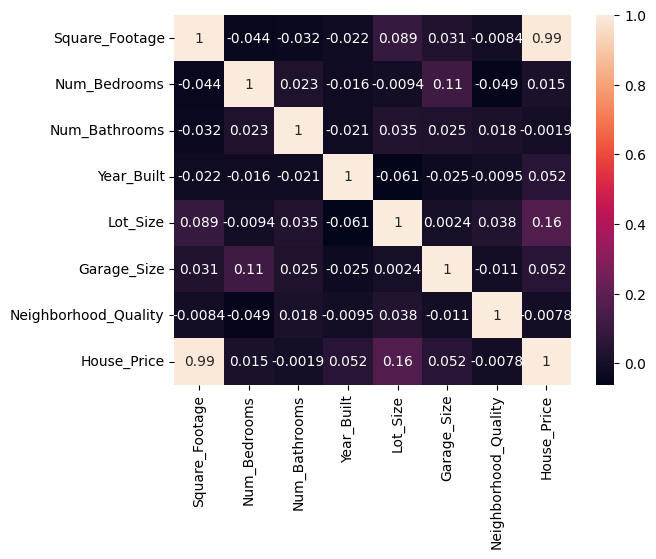

In [21]:
sns.heatmap(corr,annot=True)

**outliers**

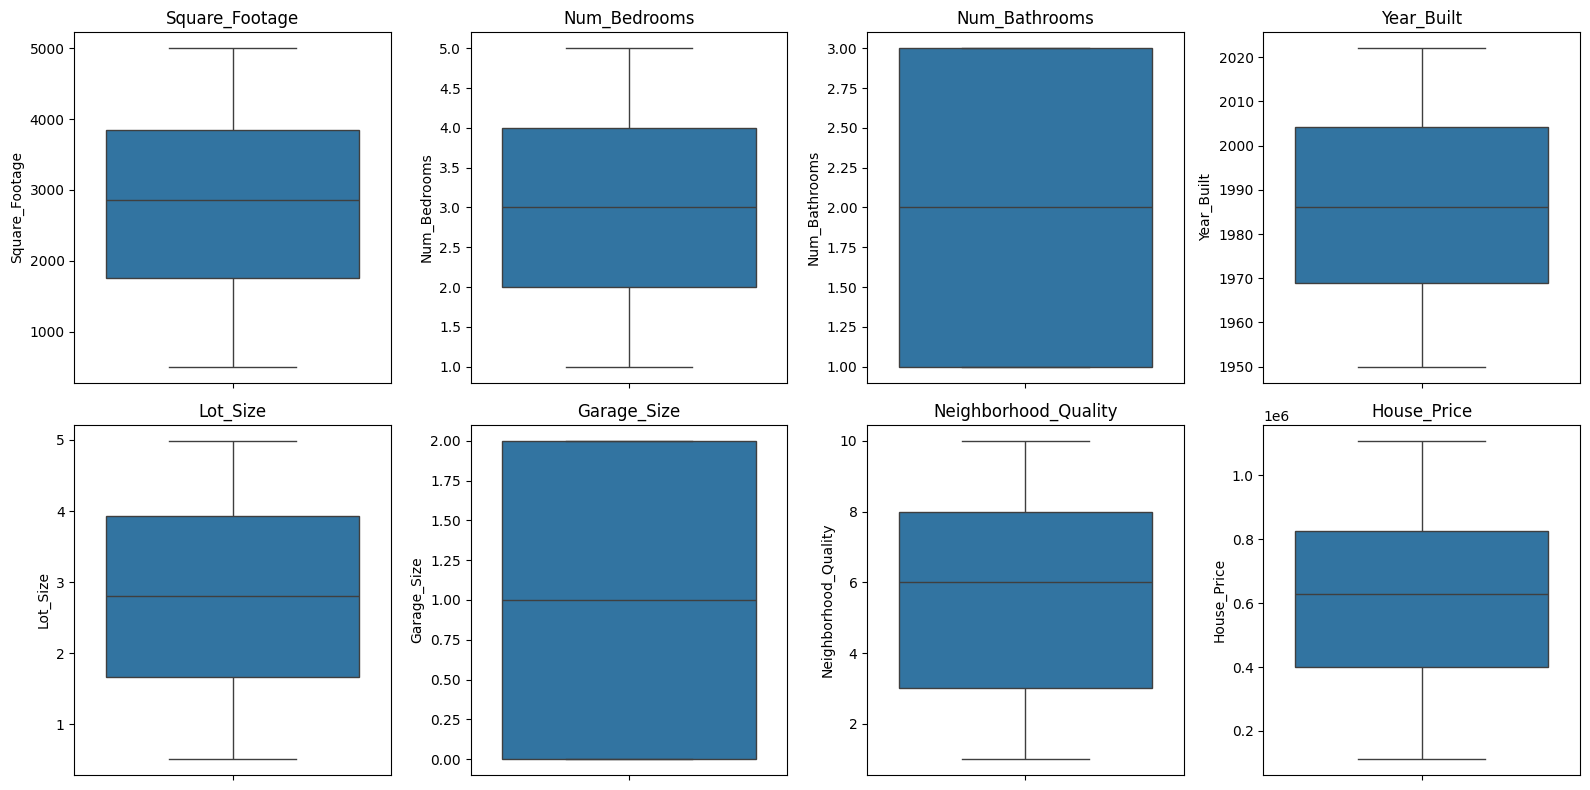

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i//4][i%4])
    axes[i//4][i%4].set_title(col)
plt.tight_layout()
plt.show()

In [26]:
Q1  = df['House_Price'].quantile(0.25)
Q3  = df['House_Price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['House_Price'] < Q1 - 1.5*IQR) |
              (df['House_Price'] > Q3 + 1.5*IQR)]
print(f"Outliers found: {len(outliers)}")

df = df[~((df['House_Price'] < Q1 - 1.5*IQR) |
          (df['House_Price'] > Q3 + 1.5*IQR))].copy()
print(f"Shape after removing outliers: {df.shape}")

Outliers found: 0
Shape after removing outliers: (1000, 8)


**encoding**



All columns are int64 or float64

No categorical variables exist — encoding not required

**Log Transformation**

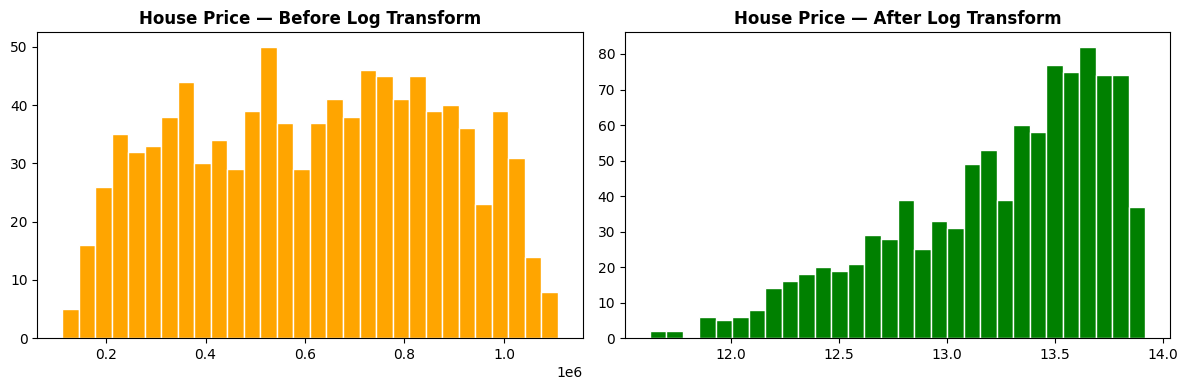

In [31]:
# Before
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['House_Price'], bins=30, color='orange', edgecolor='white')
plt.title('House Price — Before Log Transform', fontweight='bold')

# Apply log transform
df['House_Price_Log'] = np.log(df['House_Price'])

# After
plt.subplot(1, 2, 2)
plt.hist(df['House_Price_Log'], bins=30, color='green', edgecolor='white')
plt.title('House Price — After Log Transform', fontweight='bold')
plt.tight_layout()
plt.show()



separate feature and traget

In [32]:
features = ['Square_Footage','Num_Bedrooms','Num_Bathrooms',
            'Year_Built','Lot_Size','Garage_Size','Neighborhood_Quality']

X = df[features]
y = df['House_Price_Log']

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)

Features shape: (1000, 7)
Target shape:   (1000,)


train and split

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)

Training set size: (800, 7)
Test set size:     (200, 7)


scaling

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete")
print("Mean of scaled train (should be ~0):", X_train_scaled.mean().round(3))

Scaling complete
Mean of scaled train (should be ~0): 0.0


train linear ligression

In [39]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression trained successfully")
print("\nFeature Coefficients:")
for feat, coef in zip(features, lr.coef_):
    print(f"  {feat}: {coef:.4f}")

Linear Regression trained successfully

Feature Coefficients:
  Square_Footage: 0.4699
  Num_Bedrooms: 0.0314
  Num_Bathrooms: 0.0135
  Year_Built: 0.0444
  Lot_Size: 0.0391
  Garage_Size: 0.0043
  Neighborhood_Quality: 0.0051


Train KNN Regression

In [40]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Regression trained successfully")

KNN Regression trained successfully


evaluvate both methods

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(name, y_test, y_pred, X_test):
    mae    = mean_absolute_error(y_test, y_pred)
    mse    = mean_squared_error(y_test, y_pred)
    rmse   = np.sqrt(mse)
    mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2     = r2_score(y_test, y_pred)
    n, p   = X_test.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE       : {mae:.4f}")
    print(f"  MSE       : {mse:.4f}")
    print(f"  RMSE      : {rmse:.4f}")
    print(f"  MAPE      : {mape:.2f}%")
    print(f"  R²        : {r2:.4f}")
    print(f"  Adj R²    : {adj_r2:.4f}")

evaluate_model("Linear Regression", y_test, y_pred_lr, X_test_scaled)
evaluate_model("KNN Regression",    y_test, y_pred_knn, X_test_scaled)


  Linear Regression
  MAE       : 0.0908
  MSE       : 0.0129
  RMSE      : 0.1137
  MAPE      : 0.70%
  R²        : 0.9462
  Adj R²    : 0.9443

  KNN Regression
  MAE       : 0.1335
  MSE       : 0.0328
  RMSE      : 0.1810
  MAPE      : 1.03%
  R²        : 0.8638
  Adj R²    : 0.8588


actual vs predicted plot

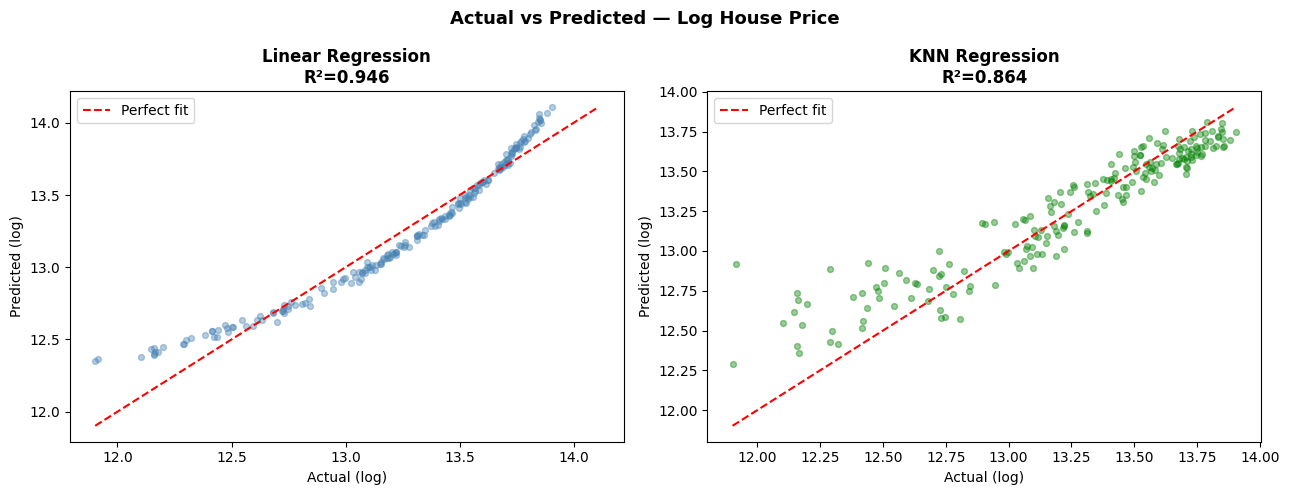

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yp, name, col in zip(axes,
                               [y_pred_lr, y_pred_knn],
                               ['Linear Regression', 'KNN Regression'],
                               ['steelblue', 'green']):
    ax.scatter(y_test, yp, alpha=0.4, color=col, s=18)
    mn = min(y_test.min(), yp.min())
    mx = max(y_test.max(), yp.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual (log)', fontsize=10)
    ax.set_ylabel('Predicted (log)', fontsize=10)
    ax.set_title(f'{name}\nR²={r2_score(y_test, yp):.3f}', fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted — Log House Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Feature Importance

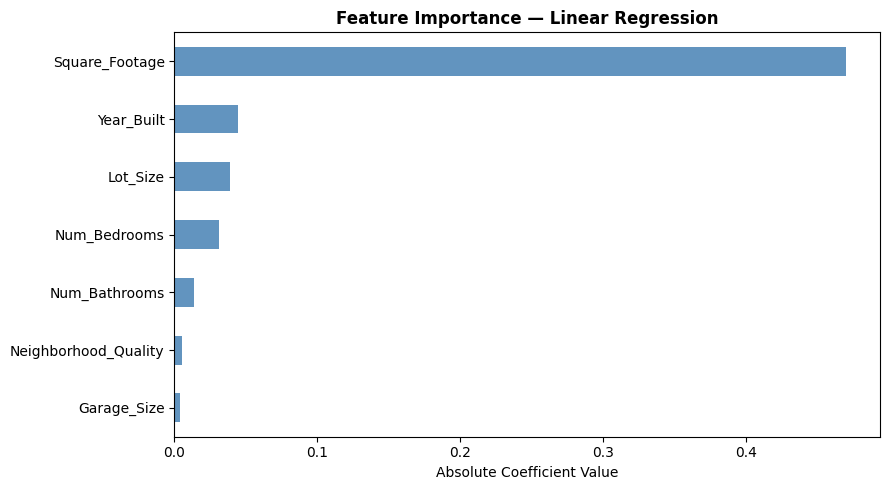

In [44]:
coefs = pd.Series(np.abs(lr.coef_), index=features).sort_values()

plt.figure(figsize=(9, 5))
coefs.plot(kind='barh', color='steelblue', alpha=0.85)
plt.title('Feature Importance — Linear Regression', fontweight='bold', fontsize=12)
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

final conculsion

In [45]:
print("=" * 50)
print("FINAL MODEL COMPARISON")
print("=" * 50)
print(f"{'Metric':<12} {'Linear Reg':>14} {'KNN':>14}")
print("-" * 42)

for name, lr_val, knn_val in [
    ("MAE",    0.0908, 0.1335),
    ("RMSE",   0.1137, 0.1810),
    ("MAPE",   0.6960, 1.0316),
    ("R²",     0.9462, 0.8638),
    ("Adj R²", 0.9443, 0.8588),
]:
    print(f"{name:<12} {lr_val:>14.4f} {knn_val:>14.4f}")

print("\nBest Model: Linear Regression")
print("Reason: Higher R² (0.946) and lower RMSE (0.114)")
print("Linear Regression explains 94.6% of variance in house prices.")

FINAL MODEL COMPARISON
Metric           Linear Reg            KNN
------------------------------------------
MAE                  0.0908         0.1335
RMSE                 0.1137         0.1810
MAPE                 0.6960         1.0316
R²                   0.9462         0.8638
Adj R²               0.9443         0.8588

Best Model: Linear Regression
Reason: Higher R² (0.946) and lower RMSE (0.114)
Linear Regression explains 94.6% of variance in house prices.
